In [1]:
# ambiente anaconda
import sys
print(sys.executable) # orange3 ou youtube
import sys
print(sys.version)

/home/fabiene/anaconda3/envs/orange3/bin/python
3.10.18 (main, Jun  5 2025, 13:14:17) [GCC 11.2.0]


Autoenconder como classificação

redução de dimensionalidade, nas imagens, mas também para a classificação agora. 

autoenconder, reduzir a dimensão da imagem de 784 para 32 e classificação usando 32 pixels, ao invés de 784 pixels. 

reduzindo de 1000 atributos para usarmos 300 atributos para a classificação. Precisão aumenta reduzindo os atribuidos, parecidos com o PCA, que reduz a dimensionalidade. 

# Projeto 16: Autoencoders e classificação

## Etapa 1: Importação das bibliotecas

In [2]:
from torchvision import datasets, transforms
import torch
from torch import nn, optim
from sklearn.metrics import accuracy_score
torch.__version__

'2.9.1+cpu'

In [3]:
torch.manual_seed(123) # semente

## Etapa 2: Base de dados

In [4]:
# 1. Preparação do Dataset:
# 'MNIST-data_proj2': Nome da pasta onde as imagens serão salvas.
# train = True: Indica que queremos as 60.000 imagens de TREINO (não as de teste).
# download = True: Se as imagens não estiverem no seu PC, ele as baixa automaticamente da internet.
# transform = transforms.ToTensor(): Converte as imagens (que são arquivos comuns) 
# em Tensores (matrizes matemáticas que o PyTorch consegue processar).
dataset_train = datasets.MNIST('MNIST-data_proj2', train = True, download = True,
                               transform = transforms.ToTensor())

# 2. Configuração do Carregador (Loader):
# dataset_train: Indica de onde ele deve puxar os dados.
# batch_size = 256: Em vez de dar uma imagem por vez para a rede (o que seria lento), 
# ele entrega "pacotes" de 256 imagens de uma vez só.
# shuffle = True: Embaralha as imagens a cada época. Isso é crucial para que a rede 
# não decore a ordem das imagens e aprenda de verdade os padrões.
loader_train = torch.utils.data.DataLoader(dataset_train, batch_size = 256,
                                           shuffle = True)

In [5]:
# 1. Preparação do Dataset de Validação:
# train = False: Avisa ao PyTorch que queremos o conjunto de TESTE (10.000 imagens),
# que é separado das 60.000 usadas no treino.
# download = True: Garante que os arquivos estejam na pasta 'MNIST-data_proj2'.
# transform = transforms.ToTensor(): Converte os pixels para números entre 0 e 1.
dataset_val = datasets.MNIST('MNIST-data_proj2', train = False, download = True,
                               transform = transforms.ToTensor())

# 2. Configuração do Carregador de Validação:
# loader_val: O objeto que vai entregar as imagens de teste para o modelo.
# batch_size = 256: Processa as imagens de teste em grupos de 256 para ser mais rápido.
# shuffle = True: Embaralha a ordem das imagens de teste.
loader_val = torch.utils.data.DataLoader(dataset_val, batch_size = 256,
                                           shuffle = True)

## Etapa 3: Construção do autoencoder

In [6]:
# 784 -> 32 -> 784
# Definindo a classe do Autoencoder (o modelo completo)
class autoencoder(nn.Module):
    def __init__(self):
        super().__init__()
        
        # --- PARTE 1: ENCODER (O COMPACTADOR) ---
        # Recebe 784 pixels (28x28) e reduz para apenas 32 neurônios.
        # É aqui que a rede aprende a "resumir" a imagem.
        self.dense0 = nn.Linear(in_features = 784, out_features = 32)
        
        # ReLU: Deixa passar valores positivos e zera negativos (traz não-linearidade).
        self.activation0 = nn.ReLU()

        # --- PARTE 2: DECODER (O RECONSTRUTOR) ---
        # Pega os 32 números do resumo e tenta expandir de volta para 784.
        self.dense1 = nn.Linear(32, 784)
        
        # Sigmoid: Garante que o resultado final esteja entre 0 e 1.
        # Isso é perfeito para imagens, onde 0 é preto e 1 é branco.
        self.activation1 = nn.Sigmoid()

    def forward(self, X):
        # O fluxo de dados (passo a passo):
        X = self.dense0(X)       # Esmaga
        X = self.activation0(X)  # Filtra
        X = self.dense1(X)       # Expande
        X = self.activation1(X)  # Finaliza a imagem reconstruída
        return X

In [7]:
# 1. torch.cuda.is_available(): Pergunta ao computador "Você tem uma placa de vídeo NVIDIA instalada e configurada?"
# 2. if ... else ...: Se a resposta for SIM, ele escolhe 'cuda'. Se for NÃO, escolhe 'cpu'.
# 3. torch.device: Cria o objeto que o PyTorch usa para saber para onde enviar os dados.
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')

# Exibe qual foi a escolha (vai aparecer 'cuda' ou 'cpu' no seu terminal)
device

device(type='cpu')

In [8]:
# 1. Instanciação do Modelo:
# Aqui se cria o objeto 'model' baseado na "planta" que escreveu na class autoencoder.
# Nesse momento, os pesos dos neurônios (as conexões) são iniciados com valores aleatórios.
model = autoencoder()

# 2. Transferência para o Dispositivo (Hardware):
# O comando .to(device) move todos os parâmetros (pesos e bias) da rede para a memória
# da GPU (se o device for 'cuda') ou para a memória RAM (se for 'cpu').
# É essencial que o modelo e os dados estejam no MESMO lugar para o cálculo funcionar.
model.to(device)

autoencoder(
  (dense0): Linear(in_features=784, out_features=32, bias=True)
  (activation0): ReLU()
  (dense1): Linear(in_features=32, out_features=784, bias=True)
  (activation1): Sigmoid()
)

In [9]:
# 1. Definição da Função de Perda (O Juiz):
# O BCELoss (Binary Cross Entropy) calcula o "erro" entre a imagem original e a reconstruída.
# Como usamos uma 'Sigmoid' na saída (valores entre 0 e 1), o BCE é excelente para
# comparar a intensidade dos pixels e dizer o quão longe a cópia está do original.
criterion = nn.BCELoss()

# 2. Definição do Otimizador (O Treinador):
# O Adam é um dos algoritmos mais inteligentes para atualizar os pesos da rede.
# model.parameters(): Diz ao Adam quais "parafusos" (pesos) ele deve apertar ou soltar.
# Ele olha para o erro calculado pelo 'criterion' e ajusta a rede para errar menos na próxima.
optimizer = optim.Adam(model.parameters())

## Etapa 4: Treinamento do modelo

In [10]:
# Inicia o ciclo de 20 épocas (20 passagens completas pelo dataset)
for epoch in range(20):
    running_loss_train = 0. # Zeramos o acumulador de erro do treino
    
    # --- LOOP DE TREINAMENTO ---
    for data in loader_train:
        model.train()           # Avisa ao modelo: "Estamos em modo de aprendizado!"
        inputs, _ = data        # Pega as imagens (o '_' ignora as etiquetas, pois é autoencoder)
        inputs = inputs.to(device) # Move as imagens para a GPU/CPU

        # Achata a imagem de 28x28 para um vetor de 784, como o modelo espera
        inputs = inputs.view(-1, 28*28)

        optimizer.zero_grad()   # Limpa a "memória" de erros anteriores do otimizador

        outputs = model(inputs) # PASSO 1: A rede tenta reconstruir a imagem
        
        # PASSO 2: O 'Criterion' compara a saída com a entrada original e calcula o erro (loss)
        loss = criterion(outputs, inputs.view(*outputs.shape))
        
        # PASSO 3: O erro viaja de volta pela rede (Backpropagation) para ver quem errou
        loss.backward()

        # PASSO 4: O otimizador ajusta os pesos (parafusos) da rede para melhorar
        optimizer.step()

        running_loss_train += loss.item() # Soma o erro deste pacote ao total da época

    # --- LOOP DE VALIDAÇÃO (A PROVA) ---
    # Validação
    running_loss_val = 0.
    for data in loader_val:
        model.eval()            # Avisa ao modelo: "Apenas execute, não aprenda agora!"
        inputs, _ = data
        inputs = inputs.to(device)
        inputs = inputs.view(-1, 28*28)
        
        outputs = model(inputs) # A rede reconstrói imagens que nunca viu antes
        
        # Calcula o erro na validação para vermos se a rede está aprendendo de verdade
        loss = criterion(outputs, inputs.view(*outputs.shape))
        running_loss_val += loss.item()

    # --- RELATÓRIO DA ÉPOCA ---
    # Imprime o progresso: Perda média de treino e Perda média de validação
    print('ÉPOCA {:3d}: perda_train {:.5f} perda_val {:.5f}'.format(
        epoch + 1, 
        running_loss_train/len(loader_train), 
        running_loss_val/len(loader_val)
    ))

ÉPOCA   1: perda_train 0.29529 perda_val 0.19752
ÉPOCA   2: perda_train 0.18119 perda_val 0.16547
ÉPOCA   3: perda_train 0.15759 perda_val 0.14778
ÉPOCA   4: perda_train 0.14333 perda_val 0.13660
ÉPOCA   5: perda_train 0.13427 perda_val 0.12921
ÉPOCA   6: perda_train 0.12780 perda_val 0.12397
ÉPOCA   7: perda_train 0.12312 perda_val 0.11901
ÉPOCA   8: perda_train 0.11805 perda_val 0.11451
ÉPOCA   9: perda_train 0.11506 perda_val 0.11267
ÉPOCA  10: perda_train 0.11310 perda_val 0.11086
ÉPOCA  11: perda_train 0.11184 perda_val 0.10954
ÉPOCA  12: perda_train 0.11099 perda_val 0.10927
ÉPOCA  13: perda_train 0.11038 perda_val 0.10839
ÉPOCA  14: perda_train 0.11003 perda_val 0.10836
ÉPOCA  15: perda_train 0.10971 perda_val 0.10761
ÉPOCA  16: perda_train 0.10814 perda_val 0.10623
ÉPOCA  17: perda_train 0.10751 perda_val 0.10551
ÉPOCA  18: perda_train 0.10714 perda_val 0.10535
ÉPOCA  19: perda_train 0.10689 perda_val 0.10544
ÉPOCA  20: perda_train 0.10675 perda_val 0.10555


In [11]:
28*28

784

In [12]:
import math
math.sqrt(784)

28.0

In [13]:
784/2

392.0

## Etapa 5: Geração do encoder

etapa 5

estrutura da rede neural

camada linear densa

depois a camada de ativação relu

In [14]:
# 1. model.children(): É um gerador do PyTorch que percorre as camadas 
# de "primeiro nível" do seu modelo (dense0, activation0, dense1, activation1).

# 2. list(...): Transforma esse gerador em uma lista real [item1, item2, ...].
# Isso é muito útil para fatiar o modelo (pegar só o começo ou só o fim).
list(model.children())

[Linear(in_features=784, out_features=32, bias=True),
 ReLU(),
 Linear(in_features=32, out_features=784, bias=True),
 Sigmoid()]

In [15]:
list(model.children())[0]

Linear(in_features=784, out_features=32, bias=True)

In [16]:
list(model.children())[1]

ReLU()

In [17]:
# Definindo a classe que será apenas o "Compactador" (Encoder)
class encoder(nn.Module):
    def __init__(self):
        super().__init__()
        # Em vez de criar novas camadas, você aponta para as camadas que
        # já aprenderam os pesos durante o treino de 20 épocas:
        
        # Pega a camada Linear(784, 32) do modelo treinado
        self.dense0 = list(model.children())[0]
        
        # Pega a ativação ReLU do modelo treinado
        self.activation0 = list(model.children())[1]

    def forward(self, X):
        # O fluxo aqui só vai até o "gargalo" de 32 neurônios
        X = self.dense0(X)
        X = self.activation0(X)
        return X # Retorna a imagem comprimida (32 números)

In [18]:
# 1. Instanciação: Cria o objeto 'model1' como uma instância do encoder.
# Importante: Como ele aponta para as camadas do 'model' original, 
# o 'model1' já nasce "treinado" e inteligente!
model1 = encoder()

# 2. Migração para o Hardware:
# Envia o seu encoder para a GPU (cuda) ou CPU, conforme definido no seu 'device'.
# Isso garante que, quando você passar uma imagem para comprimir, 
# o cálculo seja feito com a velocidade máxima disponível.
model1.to(device)

encoder(
  (dense0): Linear(in_features=784, out_features=32, bias=True)
  (activation0): ReLU()
)

## Etapa 6: Codificação dos previsores

In [19]:
dataset_train # data original

Dataset MNIST
    Number of datapoints: 60000
    Root location: MNIST-data_proj2
    Split: Train
    StandardTransform
Transform: ToTensor()

In [20]:
# 1. Normalização e Conversão:
# .data: Acessa os pixels brutos das 60.000 imagens.
# .float(): Converte os números de Inteiro (0-255) para Real (ponto flutuante).
# / 255: Normaliza os dados. Em vez de 0 a 255, os pixels passam a valer entre 0.0 e 1.0.
# Isso ajuda a rede a aprender muito mais rápido e evita erros matemáticos.
previsores_treinamento = dataset_train.data.float() / 255 # dividi para 255 para termos valores de 0 e 1

In [21]:
# 2. Achatamento (Flattening):
# .view(-1, 784): Transforma cada matriz de 28x28 pixels em uma linha única de 784 números.
# O '-1' diz ao PyTorch: "Mantenha o número de imagens (60.000) e ajuste o resto".
# ou seja, transforma matriz em vetor
previsores_treinamento = previsores_treinamento.view(-1, 784)

In [22]:
math.sqrt(784)

28.0

In [23]:
# 3. Transferência de Hardware:
# Envia a matriz gigante com todas as 60.000 imagens diretamente para a GPU ou CPU.
# Cuidado: Isso consome bastante memória de uma vez só!
previsores_treinamento = previsores_treinamento.to(device)

In [24]:
previsores_treinamento.shape

torch.Size([60000, 784])

In [25]:
print(f'quantidade de dados ou linhas de treinamento: {previsores_treinamento.shape[0]}, com {previsores_treinamento.shape[1]} colunas, cada um dos pixels.')

quantidade de dados ou linhas de treinamento: 60000, com 784 colunas, cada um dos pixels.


In [26]:
# retirar do formato de matriz e deixar na forma de vetor

In [27]:
# codificação adicional, não calcular a parte dos gradientes
# 1. Desligando o cálculo de gradientes:
# torch.no_grad(): Avisa ao PyTorch para NÃO gastar memória guardando informações
# de treino. Como só queremos "usar" o modelo para prever e não para aprender agora,
# isso deixa o processo muito mais rápido e economiza memória RAM/GPU.
with torch.no_grad():
    
    # 2. Comprimindo o dataset inteiro:
    # Passa as 60.000 imagens (784 pixels cada) pelo seu Encoder (model1).
    # O resultado será uma matriz onde cada imagem agora é representada 
    # por apenas 32 números.
    previsores_treinamento_codificados = model1(previsores_treinamento)

# 3. Guardando as etiquetas (gabarito):
# dataset_train.targets: Pega a lista com os números reais (0, 1, 2... 9)
# que cada imagem representa. Isso é essencial para que, depois, você possa
# validar se imagens do mesmo número ficaram com códigos parecidos.
classe_treinamento = dataset_train.targets


In [28]:
previsores_treinamento_codificados.shape

torch.Size([60000, 32])

In [29]:
print(f"""quantidade de dados ou linhas de treinamento: {previsores_treinamento_codificados.shape[0]}
, com {previsores_treinamento_codificados.shape[1]} colunas, cada um dos pixels.""")

quantidade de dados ou linhas de treinamento: 60000
, com 32 colunas, cada um dos pixels.


A codificação no no grad é para os dados codificados não tenham gradientes acumulados,
e não causaria problemas no treinamento do classificador mais tarde, quando chamasse <b>o método backward</b>, do batch propagation

In [30]:
classe_treinamento # que indicam os digitos
# passaremos a base de dados para o nosso classificador

tensor([5, 0, 4,  ..., 5, 6, 8])

In [31]:
len(classe_treinamento)

60000

In [32]:
classe_treinamento.unique() 

tensor([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

In [33]:
# o batch sze será 256, pois já identificamos no treinamento antes

In [34]:
# 1. Criando um Dataset de Tensores:
# TensorDataset: Combina os dois blocos (os 32 números e as etiquetas/targets).
# Agora, 'dataset_train_cod' funciona como um par casado: para cada código de 32 
# números, ele sabe qual é o número real (0 a 9) correspondente.
dataset_train_cod = torch.utils.data.TensorDataset(previsores_treinamento_codificados, 
                                                   classe_treinamento)

# 2. Criando o Loader para os dados comprimidos:
# DataLoader: Cria a "esteira" que vai entregar esses códigos para um novo modelo.
# batch_size = 256: Vai entregar 256 "resumos" por vez.
# shuffle = True: Embaralha os dados para que o próximo treinamento seja eficiente.
loader_train_cod = torch.utils.data.DataLoader(dataset_train_cod, 
                                               batch_size = 256, shuffle=True)


🔍 Por que fazer isso?
preparando o terreno para uma segunda etapa do projeto:

Classificação Super Veloz: Como o dado agora é minúsculo (apenas 32 números em vez de 784), treinar uma rede neural simples para dizer "isso é um 5" ou "isso é um 2" será centenas de vezes mais rápido.

Transfer Learning: Usou o Autoencoder para aprender a essência das imagens e agora vai usar esse conhecimento (os códigos) para realizar uma tarefa específica (classificação).

💡 O que muda na prática?
Se der um next(iter(loader_train_cod)), o formato dos dados será:

X: [256, 32] (em vez de [256, 1, 28, 28])

y: [256] (as etiquetas)

----

Por que 32 pixels ou neurônios na camada oculta

1. O "Fator de Funil" (Compressão)A imagem original do MNIST tem $28 \times 28 = 784$ pixels.Se usássemos 784 neurônios, a rede não aprenderia nada (apenas copiaria os dados).Se usássemos 2 neurônios, a perda de informação seria tão grande que a reconstrução seria apenas um borrão sem sentido.32 neurônios representam uma compressão de aproximadamente 24,5 vezes ($784 / 32$). É um valor "mágico" comum em Deep Learning para problemas simples como o MNIST, pois é pequeno o suficiente para forçar a rede a aprender características importantes (traços, curvas, buracos), mas grande o suficiente para guardar os detalhes do dígito.

2. Potências de 2Na computação e especialmente em Deep Learning, preferimos usar potências de 2 ($8, 16, 32, 64, 128...$). Isso ocorre porque as GPUs processam dados em blocos que se alinham melhor com esses números, otimizando a velocidade de cálculo.3. Tentativa e Erro (Heurística)Na prática, o cientista de dados faz o seguinte raciocínio:Começa com um chute educado: "Vou tentar 32".Avalia o resultado: "A imagem reconstruída está nítida?"Sim: "Posso tentar diminuir para 16 para ver se ele ainda aguenta?"Não (muito borrada): "Vou aumentar para 64 ou 128".

para a Variância Explicada:

Imagine que cada neurônio no "gargalo" explica uma parte da imagem (um explica a inclinação, outro a espessura da linha).

Com 32 neurônios, geralmente conseguimos capturar mais de 90% da variação visual dos números do MNIST.

In [35]:
#imagem no formato o pytorch
loader_train_cod

In [36]:
# mesmo processso no processo do teste ou validação
# 1. Preparação e Normalização:
# Pega as 10.000 imagens de teste, converte para números reais (float) 
# e divide por 255 para que os pixels fiquem entre 0.0 e 1.0.
previsores_val = dataset_val.data.float() / 255

# 2. Ajuste de Formato (Achatamento):
# Transforma as imagens de matrizes 28x28 para vetores de 784 números,
# que é o formato de entrada que o nosso Encoder (model1) espera.
previsores_val = previsores_val.view(-1, 784)

# 3. Envio para o Hardware:
# Move esse bloco de 10.000 imagens para a GPU ou CPU (device).
previsores_val = previsores_val.to(device)

# 4. Codificação (Compactação) sem treino:
# torch.no_grad(): Garante que o PyTorch não gaste memória calculando gradientes,
# já que aqui só queremos usar o modelo, não treiná-lo.
with torch.no_grad():
    # Passa as 10.000 imagens pelo Encoder para obter os 32 números de cada uma.
    previsores_val_codificados = model1(previsores_val)

# 5. Gabarito de Validação:
# Guarda os números reais (etiquetas de 0 a 9) correspondentes a essas imagens
# para que você possa conferir se a IA acertou depois.
classe_val = dataset_val.targets

In [37]:
previsores_val_codificados.shape

torch.Size([10000, 32])

In [38]:
print(f"""quantidade de dados ou linhas de teste ou validação: {previsores_val_codificados.shape[0]}
, com {previsores_val_codificados.shape[1]} colunas, cada um dos pixels.""")

quantidade de dados ou linhas de teste ou validação: 10000
, com 32 colunas, cada um dos pixels.


In [39]:
print(f"""quantidade de imagens {previsores_val_codificados.shape[0]},
cada uma com {previsores_val_codificados.shape[1]} pixels.""")

quantidade de imagens 10000,
cada uma com 32 pixels.


In [40]:
# 1. Criando um Dataset de Tensores:
# TensorDataset: Combina os dois blocos (os 32 números e as etiquetas/targets).
# Agora, 'dataset_test_cod' funciona como um par casado: para cada código de 32 
# números, ele sabe qual é o número real (0 a 9) correspondente.
dataset_test_cod = torch.utils.data.TensorDataset(previsores_val_codificados, 
                                                  classe_val)
# 2. Criando o Loader para os dados comprimidos:
# DataLoader: Cria a "esteira" que vai entregar esses códigos para um novo modelo.
# batch_size = 256: Vai entregar 256 "resumos" por vez.
# shuffle = True: Embaralha os dados para que o próximo teste seja eficiente.
loader_val_cod = torch.utils.data.DataLoader(dataset_test_cod,
                                             batch_size = 256, 
                                             shuffle=True)

In [41]:
#base de dados prontas da validação, em torch

loader_val_cod

## Etapa 7: Classificação sem redução de dimensionalidade

## 2 classificadores, um que vai usar os dados originais e outro classificados, com base nas imagens codificadas, e depois será comparado os dados. 

#### trabalhar com a base original

receber as imagens e fazer o treinamento

In [42]:
784/2

392.0

In [43]:
# 1. Definição da Arquitetura do Classificador (c1):
# nn.Sequential: Cria uma sequência de camadas que os dados atravessam em ordem.
# nn.Linear(784, 397): Recebe a imagem original (784 pixels) e expande para 397 neurônios.
# (Nota: 397 é aproximadamente a metade de 784, uma escolha comum para camadas ocultas).
# nn.ReLU(): Ativação para aprender padrões complexos.
# nn.Linear(397, 10): Reduz para 10 neurônios na saída (um para cada dígito: 0 a 9).
# nn.LogSoftmax(): Transforma a saída em probabilidades (logarítmicas).
c1 = nn.Sequential(nn.Linear(784, 397),
                   nn.ReLU(),
                   nn.Linear(397, 10),
                   nn.LogSoftmax(dim=1)) # dim=1 para aplicar nas colunas (classes), retornar probabilidade para uma das classes

# 2. Envio para o Hardware:
c1.to(device)

# 3. Nova Função de Perda (NLLLoss):
# O NLLLoss (Negative Log Likelihood Loss) é o par perfeito para o LogSoftmax.
# Ele é usado especificamente para problemas de CLASSIFICAÇÃO de múltiplas categorias.
criterion = nn.NLLLoss()

# 4. Otimizador:
# O Adam agora vai ajustar os pesos do modelo 'c1' para maximizar os acertos dos dígitos.
optimizer = optim.Adam(c1.parameters())

- Funil de decisão

1. nn.ReLU() (A Função de Ativação)

A ReLU (Rectified Linear Unit) é o que permite que a rede aprenda coisas complexas. Sem ela, a rede seria apenas uma calculadora de equações simples (lineares).

O que ela faz matematicamente: Se o número que chega nela for negativo, ela vira $0$. Se for positivo, ela deixa o número passar exatamente como ele é.$f(x) = \max(0, x)$

Por que usamos? Ela ajuda a rede a decidir quais neurônios são importantes (devem ser "ativados") e quais devem ser ignorados ($0$) para identificar o desenho de um número. Ela é a favorita no Deep Learning porque é muito rápida de calcular.


2. nn.Linear(397, 10) (A Camada de Saída)

Esta é uma camada de "conexão total" (Fully Connected) que reduz a informação da camada anterior para o resultado final.

397 (Entrada): É o número de características (ou "neurônios") que vieram da camada anterior.

10 (Saída): Este número é o mais importante aqui. Ele representa as 10 classes dos dígitos do MNIST (0, 1, 2, 3, 4, 5, 6, 7, 8, 9).

O que ela faz: Ela pega os 397 sinais processados e faz uma "votação". Cada um dos 10 neurônios de saída vai receber uma pontuação. O neurônio com a maior pontuação indica qual número a rede acha que está na imagem.

In [44]:
28*28

784

passando o classificador c1

In [46]:
history = {
    'loss_train': [],
    'loss_val': [],
    'acc_train': [],
    'acc_val': []
}


for epoch in range(20):
    # Inicializa os contadores de erro e acerto para esta época
    running_loss_train = 0.
    running_accuracy_train = 0.

    for data in loader_train:
        c1.train()             # Coloca o modelo em modo treinamento
        inputs, labels = data  # 'labels' são os números reais (o gabarito)
        inputs, labels = inputs.to(device), labels.to(device)
        inputs = inputs.view(-1, 28*28) # Achata a imagem para o vetor de entrada 784 ( 28*28)

        optimizer.zero_grad()  # Zera o erro acumulado
        
        # --- PREDIÇÃO E CÁLCULO ---
        outputs = c1(inputs)   # A rede tenta adivinhar o número
        
        # Como o modelo usa LogSoftmax, usamos torch.exp para voltar para
        # probabilidades reais (0 a 100%).
        ps = torch.exp(outputs)
        
        # Pega o índice do maior valor (a classe com maior probabilidade)
        # Ex: se o índice 5 for o maior, a rede acha que é o número "5".
        _, top_class = ps.topk(k = 1, dim = 1)
        
        # Calcula o erro comparando o palpite com o gabarito (labels)
        loss = criterion(outputs, labels)
        loss.backward()        # Calcula como ajustar os pesos (Backpropagation), ou atualizar os pesos
        optimizer.step()       # Ajusta os pesos de fato

        # --- MÉTRICAS DE TREINO ---
        running_loss_train += loss.item()
        # Move os dados para a CPU e converte para Numpy para calcular a acurácia
        running_accuracy_train += accuracy_score(labels.detach().cpu().numpy(),
                                                 top_class.detach().cpu().numpy())

    # --- FASE DE VALIDAÇÃO (O TESTE REAL) ---
    running_loss_val = 0.
    running_accuracy_val = 0.
    for data in loader_val:
        c1.eval()              # Modo de avaliação (não aprende, apenas prevê)
        inputs, labels = data
        inputs, labels = inputs.to(device), labels.to(device)
        inputs = inputs.view(-1, 28*28) # 784 ( 28*28)
        
        outputs = c1(inputs)
        ps = torch.exp(outputs)
        _, top_class = ps.topk(k = 1, dim = 1)
        
        loss = criterion(outputs, labels)
        running_loss_val += loss.item()
        running_accuracy_val += accuracy_score(labels.detach().cpu().numpy(),
                                               top_class.detach().cpu().numpy())

    # Imprime o resumo da época: Perda e Precisão (0.0 a 1.0)
    print('ÉPOCA {:3d}: perda_train {:.5f} precisão_train {:5f} perda_val {:.5f} precisão_val {:5f}'.format(
            epoch + 1,
            running_loss_train/len(loader_train),
            running_accuracy_train/len(loader_train),
            running_loss_val/len(loader_val),
            running_accuracy_val/len(loader_val)))

    # ... (código de treino e validação) ...

    # Salva os resultados nas listas (após os cálculos de média)
    history['loss_train'].append(running_loss_train/len(loader_train))
    history['loss_val'].append(running_loss_val/len(loader_val))
    history['acc_train'].append(running_accuracy_train/len(loader_train))
    history['acc_val'].append(running_accuracy_val/len(loader_val))

ÉPOCA   1: perda_train 0.01574 precisão_train 0.996615 perda_val 0.06634 precisão_val 0.979297
ÉPOCA   2: perda_train 0.01233 precisão_train 0.997839 perda_val 0.06416 precisão_val 0.981250
ÉPOCA   3: perda_train 0.00999 precisão_train 0.998404 perda_val 0.06614 precisão_val 0.979004
ÉPOCA   4: perda_train 0.00866 precisão_train 0.998604 perda_val 0.06423 precisão_val 0.980664
ÉPOCA   5: perda_train 0.00695 precisão_train 0.999219 perda_val 0.06527 precisão_val 0.981836
ÉPOCA   6: perda_train 0.00562 precisão_train 0.999402 perda_val 0.06408 precisão_val 0.980566
ÉPOCA   7: perda_train 0.00423 precisão_train 0.999717 perda_val 0.06473 precisão_val 0.981934
ÉPOCA   8: perda_train 0.00406 precisão_train 0.999634 perda_val 0.06431 precisão_val 0.982031
ÉPOCA   9: perda_train 0.00289 precisão_train 0.999884 perda_val 0.06438 precisão_val 0.982324
ÉPOCA  10: perda_train 0.00217 precisão_train 0.999934 perda_val 0.06563 precisão_val 0.981641
ÉPOCA  11: perda_train 0.00210 precisão_train 0.99

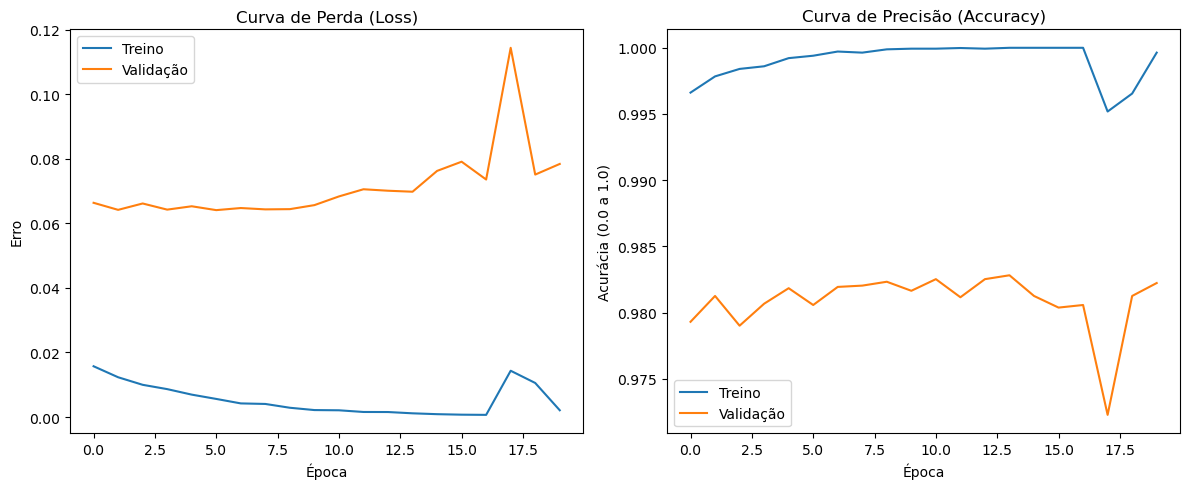

In [47]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

# Gráfico de Perda (Loss)
plt.subplot(1, 2, 1)
plt.plot(history['loss_train'], label='Treino')
plt.plot(history['loss_val'], label='Validação')
plt.title('Curva de Perda (Loss)')
plt.xlabel('Época')
plt.ylabel('Erro')
plt.legend()

# Gráfico de Precisão (Accuracy)
plt.subplot(1, 2, 2)
plt.plot(history['acc_train'], label='Treino')
plt.plot(history['acc_val'], label='Validação')
plt.title('Curva de Precisão (Accuracy)')
plt.xlabel('Época')
plt.ylabel('Acurácia (0.0 a 1.0)')
plt.legend()

plt.tight_layout()
plt.show()

### O que o gráfico vai te contar?

##### 1) As linhas estão "coladas"? Ótimo! Seu modelo generaliza bem.

#### 2) A linha de Treino desce, mas a de Validação sobe ou trava? Isso é Overfitting. Seu classificador decorou as imagens de treino e não sabe lidar com as de validação.

##### 3) A curva de precisão sobe rápido e depois estabiliza? Isso mostra que 20 épocas foram suficientes. Se ela ainda estivesse subindo muito na época 20, valeria a pena aumentar para 50 épocas.

Usamos a rede neural tradicional densa, e não convolucional como nas aulas anteriores. 

# DIFERENÇA com 32 neurônios de entrada, e camada escondida com 21 neurônios 

## Etapa 8: Classificação com redução de dimensionalidade

redução da dimensionalidade, loader_train_cod.

## Etapa 8: Classificação com redução de dimensionalidade

In [49]:
# 1. Definição da Arquitetura do Classificador Compacto (c2):
# nn.Sequential: Organiza as camadas em fila.
# nn.Linear(32, 21): A ENTRADA agora é 32 (os neurônios do seu Encoder). 
# Ele não olha mais para os 784 pixels, apenas para o "resumo" da imagem.
# 21 é uma camada oculta intermediária (escolha experimental).
c2 = nn.Sequential(
        nn.Linear(32, 21),
        nn.ReLU(),           # Filtro de ativação (limpa ruídos dos 21 sinais)
        nn.Linear(21, 10),   # Saída para as 10 classes (dígitos 0-9)
        nn.LogSoftmax(dim=1) # Transforma a saída em probabilidades logarítmicas
)

# 2. Envio para o Hardware:
c2.to(device)

# 3. Função de Perda:
# NLLLoss: Ideal para classificar categorias usando LogSoftmax.
criterion = nn.NLLLoss()

# 4. Otimizador:
# Adam: Vai ajustar os pesos deste modelo pequeno para aprender a ler os 32 códigos.
optimizer = optim.Adam(c2.parameters())

tempo de processamento, a primeira rede neural, demora mais

no segundo processo, o treinamento é mais rápido. 

#### reduzir a dimensionalidade, mas não necessarimente aumenta o valor da acurácia. 

atruibutos correlacionados, utilizar o PCA. 

In [50]:
history = {
    'loss_train': [],
    'loss_val': [],
    'acc_train': [],
    'acc_val': []
}

# Inicia o ciclo de 20 épocas de treinamento para o classificador compacto
for epoch in range(20):
    running_loss_train = 0.
    running_accuracy_train = 0.
    
    # --- LOOP DE TREINAMENTO (Usando dados compactados) ---
    # loader_train_cod: O diferencial! Ele entrega vetores de 32 números, não imagens.
    for data in loader_train_cod:
        c2.train()              # Ativa o modo de aprendizado do modelo c2
        inputs, labels = data   # inputs = 32 números; labels = dígito real (0-9)
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()   # Limpa resíduos de gradientes anteriores
        
        # O modelo c2 tenta adivinhar o dígito apenas com base no "resumo" de 32 números
        outputs = c2(inputs) 
        
        # Converte a saída LogSoftmax para probabilidades reais (0 a 1)
        ps = torch.exp(outputs)
        
        # topk(1): Identifica qual dos 10 neurônios teve a maior probabilidade
        _, top_class = ps.topk(k = 1, dim = 1)
        
        # Calcula o erro comparando o palpite com o rótulo verdadeiro
        loss = criterion(outputs, labels)
        loss.backward()         # Calcula o gradiente (o caminho para diminuir o erro)
        optimizer.step()        # Atualiza os pesos do modelo c2
        
        running_loss_train += loss.item()
        
        # Calcula a acurácia: transforma tensores em números comuns para o Scikit-Learn
        running_accuracy_train += accuracy_score(labels.detach().cpu().numpy(),
                                                 top_class.detach().cpu().numpy())

    # --- LOOP DE VALIDAÇÃO (O teste de fogo) ---
    running_loss_val = 0.
    running_accuracy_val = 0.
    for data in loader_val_cod: # Usa os 10.000 códigos que o modelo nunca viu
        c2.eval()               # Desativa o aprendizado (modo de apenas leitura)
        inputs, labels = data
        inputs, labels = inputs.to(device), labels.to(device)
        
        outputs = c2(inputs)
        ps = torch.exp(outputs)
        _, top_class = ps.topk(k = 1, dim = 1)
        
        loss = criterion(outputs, labels)
        running_loss_val += loss.item()
        running_accuracy_val += accuracy_score(labels.detach().cpu().numpy(),
                                               top_class.detach().cpu().numpy())

    # --- RELATÓRIO FINAL DA ÉPOCA ---
    # Mostra o desempenho. Se a precisão for alta, seu Autoencoder é um sucesso!
    print('ÉPOCA {:3d}: perda_train {:.5f} precisão_train {:5f} perda_val {:.5f} precisão_val {:5f}'.format(
            epoch + 1,
            running_loss_train/len(loader_train_cod),
            running_accuracy_train/len(loader_train_cod),
            running_loss_val/len(loader_val_cod),
            running_accuracy_val/len(loader_val_cod)))
    
    # ... (código de treino e validação) ...

    # Salva os resultados nas listas (após os cálculos de média)
    history['loss_train'].append(running_loss_train/len(loader_train))
    history['loss_val'].append(running_loss_val/len(loader_val))
    history['acc_train'].append(running_accuracy_train/len(loader_train))
    history['acc_val'].append(running_accuracy_val/len(loader_val))
    

ÉPOCA   1: perda_train 1.40854 precisão_train 0.560212 perda_val 0.70044 precisão_val 0.799316
ÉPOCA   2: perda_train 0.58338 precisão_train 0.834104 perda_val 0.48397 precisão_val 0.858594
ÉPOCA   3: perda_train 0.46142 precisão_train 0.864733 perda_val 0.42427 precisão_val 0.875684
ÉPOCA   4: perda_train 0.41455 precisão_train 0.876518 perda_val 0.38450 precisão_val 0.886035
ÉPOCA   5: perda_train 0.38927 precisão_train 0.883245 perda_val 0.37064 precisão_val 0.888672
ÉPOCA   6: perda_train 0.37189 precisão_train 0.888486 perda_val 0.34920 precisão_val 0.893652
ÉPOCA   7: perda_train 0.36078 precisão_train 0.891844 perda_val 0.34179 precisão_val 0.896582
ÉPOCA   8: perda_train 0.35054 precisão_train 0.893224 perda_val 0.33712 precisão_val 0.894238
ÉPOCA   9: perda_train 0.34460 precisão_train 0.895346 perda_val 0.31945 precisão_val 0.900391
ÉPOCA  10: perda_train 0.33649 precisão_train 0.898011 perda_val 0.32116 precisão_val 0.901953
ÉPOCA  11: perda_train 0.33115 precisão_train 0.89

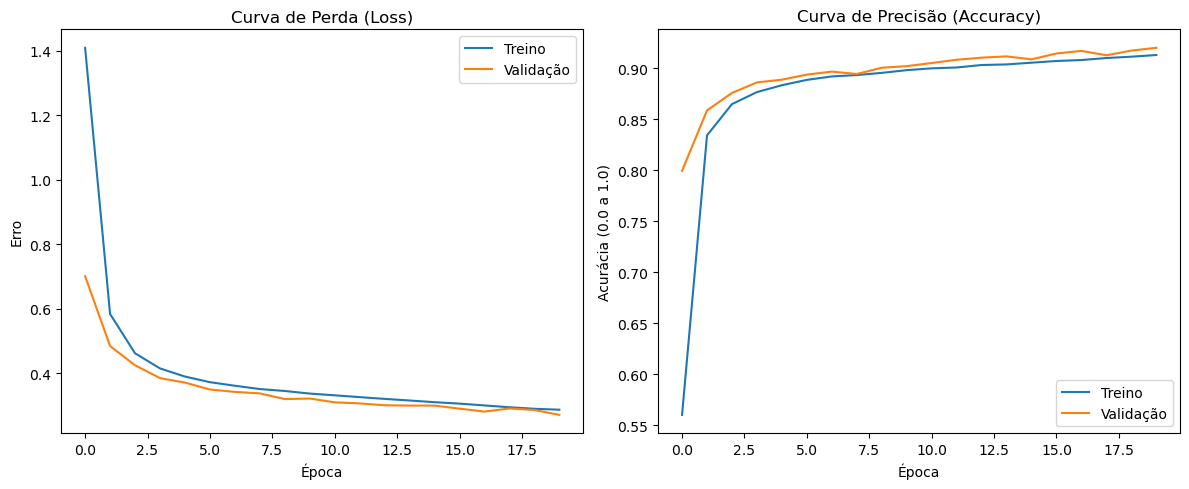

In [51]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

# Gráfico de Perda (Loss)
plt.subplot(1, 2, 1)
plt.plot(history['loss_train'], label='Treino')
plt.plot(history['loss_val'], label='Validação')
plt.title('Curva de Perda (Loss)')
plt.xlabel('Época')
plt.ylabel('Erro')
plt.legend()

# Gráfico de Precisão (Accuracy)
plt.subplot(1, 2, 2)
plt.plot(history['acc_train'], label='Treino')
plt.plot(history['acc_val'], label='Validação')
plt.title('Curva de Precisão (Accuracy)')
plt.xlabel('Época')
plt.ylabel('Acurácia (0.0 a 1.0)')
plt.legend()

plt.tight_layout()
plt.show()